In [1]:
import sys
sys.path.append('../pyquity')

In [ ]:
import pyquity
import warnings
import osmnx as ox
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
ox.settings.use_cache = False
warnings.filterwarnings('ignore')

In [4]:
PLACE_NAME = 'Calgary, Canada'

In [ ]:
# Create base graphs
G_walk = pyquity.graph_from_place(PLACE_NAME, network_type='walk')
G_bike = pyquity.graph_from_place(PLACE_NAME, network_type='bike')

# Create GTFS graph (GTFS zip file)
G_gtfs = pyquity.graph_from_gtfs('/Users/net/Downloads/calgary.zip')

# Combine base graphs with GTFS graph
MG_walk = pyquity.multimodal_graph(G_walk, G_gtfs)
MG_bike = pyquity.multimodal_graph(G_bike, G_gtfs)

In [ ]:
# Create amenity
amenity = pyquity.amenity_from_place(PLACE_NAME, amenity_type='all')

# Create grid
grid = pyquity.grid_from_place(PLACE_NAME, grid_size=500)

# Add amenity and micromobility into grid
grid = pyquity.amenity_in_grid(grid, amenity)
grid = pyquity.micromobility_in_grid(grid, micromobility_size=2000)

# Create equity properties
equity = pyquity.Equity(MG_walk, MG_bike, grid, amenity)

In [ ]:
# Optional: select multiple amenity types
amenity = pyquity.amenity_from_place('Barrie, Canada', amenity_type=['education', 'healthcare'])

In [31]:
grid = equity.sufficientarianism(served_time=5, weight='travel_time')
gini, lorenz = equity.egalitarianism(grid)
grid = equity.utilitarianism(served_time=5, weight='travel_time')

In [ ]:
print("Sufficientarian Coverage:", grid['served'].mean() * 100)
print("Egalitarian Gini Coefficient:", gini)
print("Utilitarian Avg. Accessibility:", grid['count_served'].mean())

Sufficientarian Coverage: 27.686753679533467
Egalitarian Gini Coefficient: 0.7231324632046654
Utilitarian Avg. Accessibility: 4.067481255206887


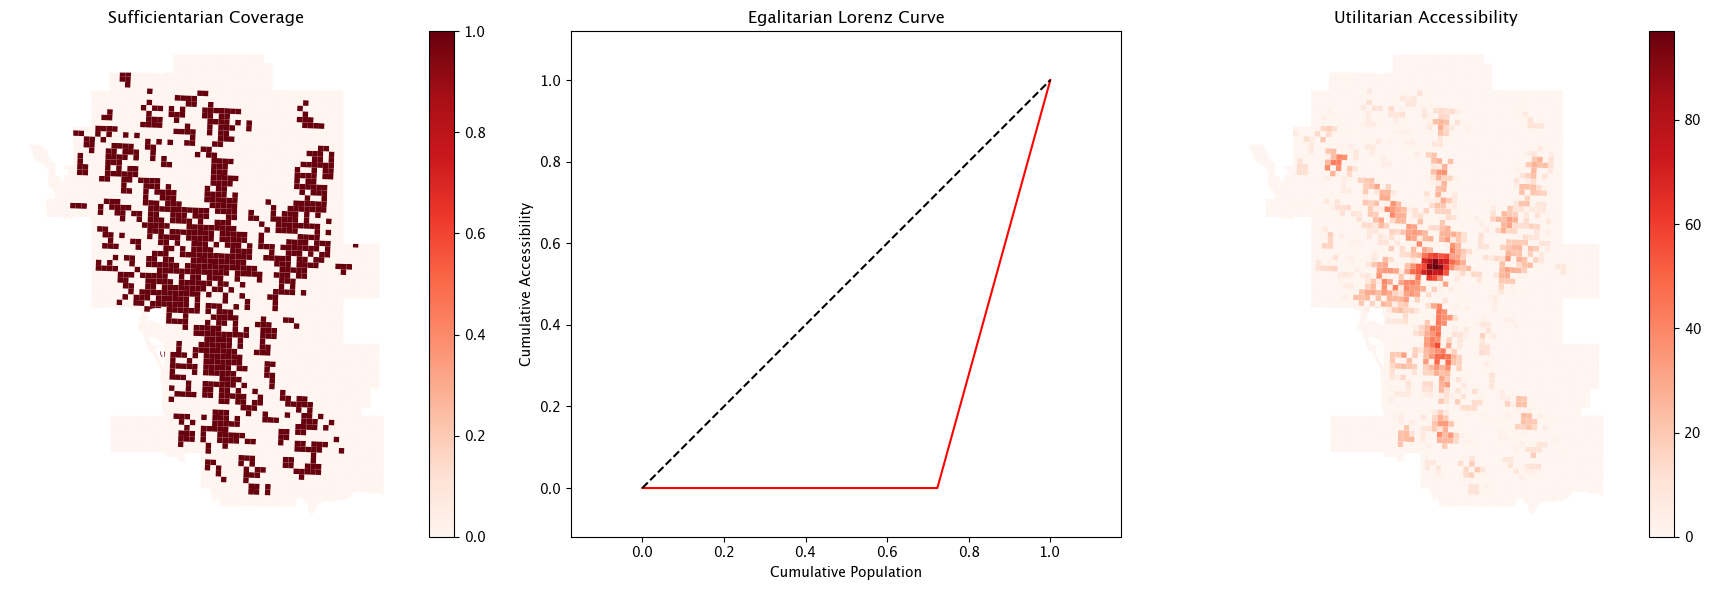

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
grid.plot(column='served', cmap='Reds', ax=ax[0], legend=True)
ax[0].set_title('Sufficientarian Coverage')
ax[0].axis('off')
ax[1].plot(np.linspace(0, 1, len(lorenz)), lorenz, color='red')
ax[1].plot([0, 1], [0, 1], color='black', linestyle='--')
ax[1].set_title('Egalitarian Lorenz Curve')
ax[1].set_xlabel('Cumulative Population')
ax[1].set_ylabel('Cumulative Accessibility')
ax[1].axis('equal')
grid.plot(column='count_served', cmap='Reds', ax=ax[2], legend=True)
ax[2].set_title('Utilitarian Accessibility')
ax[2].axis('off')
plt.tight_layout()
plt.show()